### Plot sample results
This notebook shows plots from the run conducted in fullRun.sh or sampleRun.sh, depending on what is available.  You need to run one of those scripts prior to using this notebook in order to generate the data files used here.

Two sets of plots are generated.  The first shows the time histories of $\min(n_e)$, $\max(n_e)$, $\min(T_e)$ and $\max(T_e)$.  This data is dumped to the screen for every time step, which is captured in run.out (for sampleRun.sh) or fullRun.out (for fullRun.sh).  The second set of plots shows $n_e$, $n_i$, and $T_e$ as a function of $x$ for the snapshots stored in the restart files.

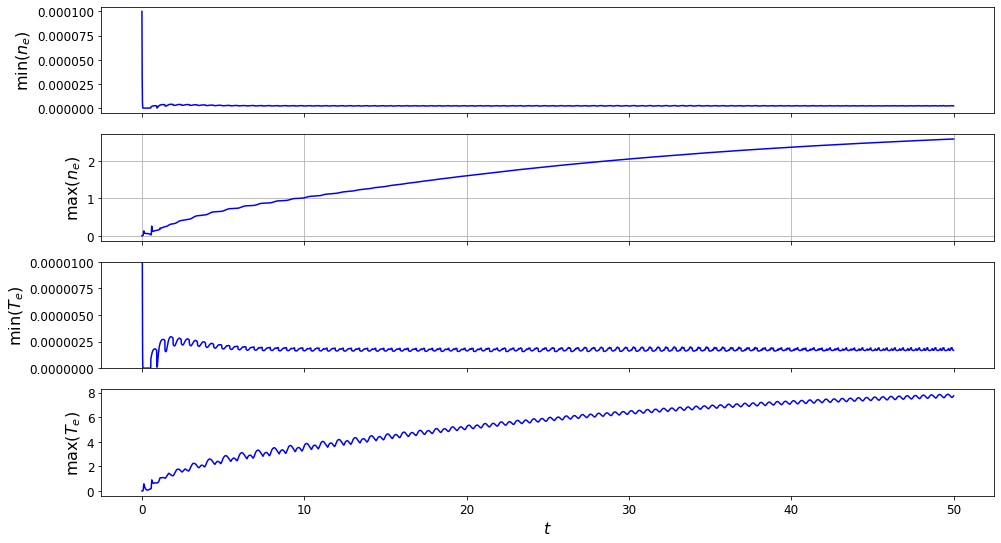

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from os import path

## check what result is available
#if (path.isfile('fullRun.out')):
#    # if we have a long run, plot that
#    D = np.loadtxt('fullRun.out')
#elif (path.isfile('run.out')):
#    # otherwise, try short run
#    D = np.loadtxt('run.out')
#else:
#    print("Don't have any data!  Plotting will fail.")

    
D = np.loadtxt('run.out')

plt.figure(figsize=(16,9))
ax0 = plt.subplot(4,1,1)
ax0.plot(D[:,0], D[:,1], 'b-')
plt.setp(ax0.get_xticklabels(),visible=False)
plt.setp(ax0.get_yticklabels(),fontsize=12)
ax0.set_ylabel(r'$\min(n_e)$', fontsize=16)

ax1 = plt.subplot(4,1,2,sharex=ax0)
ax1.plot(D[:,0], D[:,2], 'b-')
#ax1.set_ylim(0.85,1.1)
ax1.grid()
plt.setp(ax1.get_xticklabels(),visible=False)
plt.setp(ax1.get_yticklabels(),fontsize=12)
ax1.set_ylabel(r'$\max(n_e)$', fontsize=16)

ax2 = plt.subplot(4,1,3,sharex=ax0)
ax2.plot(D[:,0], D[:,3], 'b-')
plt.ylim(0,1e-5)
plt.setp(ax2.get_xticklabels(),visible=False)
plt.setp(ax2.get_yticklabels(),fontsize=12)
ax2.set_ylabel(r'$\min(T_e)$', fontsize=16)

ax3 = plt.subplot(4,1,4,sharex=ax0)
ax3.plot(D[:,0], D[:,4], 'b-')
#plt.ylim(0,1e-5)
plt.setp(ax3.get_xticklabels(),fontsize=12)
plt.setp(ax3.get_yticklabels(),fontsize=12)
ax3.set_ylabel(r'$\max(T_e)$', fontsize=16)
ax3.set_xlabel(r'$t$', fontsize=16)

plt.show()

# The non-dimensional transport and chemstry properties are
#   De    = 3.536159e-01
#   Di    = 1.896334e-05
#   mue   = 8.849558e+01
#   mui   = 4.259880e-01
#   Ck    = 2.932670e+02
#   A     = 2.803050e+01
#   dH    = 1.570000e+01
#   qStar = 1.000000e+03
#   alpha = 3.611738e+01
#   ks    = 1.755162e+00
#   gam   = 1.000000e-02
['restart_psaap_Np250_T10.npy', 'restart_psaap_Np250_T20.npy', 'restart_psaap_Np250_T30.npy', 'restart_psaap_Np250_T40.npy', 'restart_psaap_Np250_T50.npy']


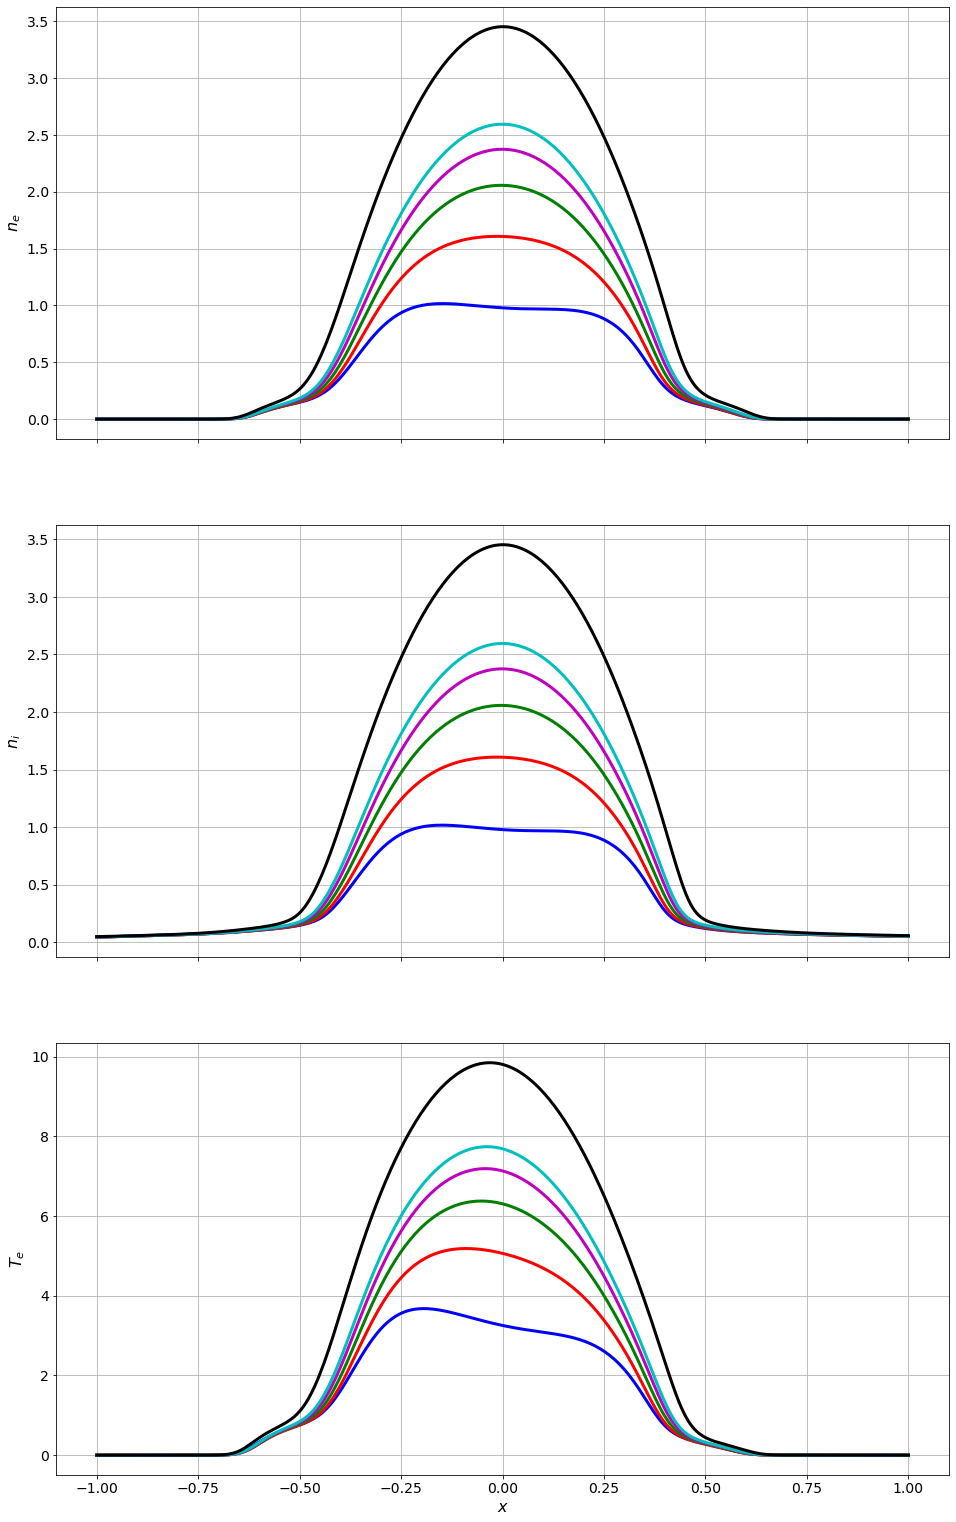

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os, fnmatch
import chebSolver as cs

tds = cs.timeDomainCollocationSolver(2,1,250)

#files = fnmatch.filter(os.listdir('.'), 'restart_Np150_*.npy')
files = fnmatch.filter(os.listdir('.'), 'restart_psaap_Np250_*.npy')
files.sort()
print(files)
cols = ['b-', 'r-', 'g-', 'm-', 'c-', 'k-', 'b--', 'r--', 'g--']

files.append('newton_psaap_Np250.npy')

#or file, col in zip(files, cols):
#    print("Plotting {0:s} with {1:s}".format(file,col),flush=True)

create = True
for file, col in zip(files, cols):
    tds.U2 = np.load(file)
    tds.plot(col,create)
    create = False
    
plt.show()

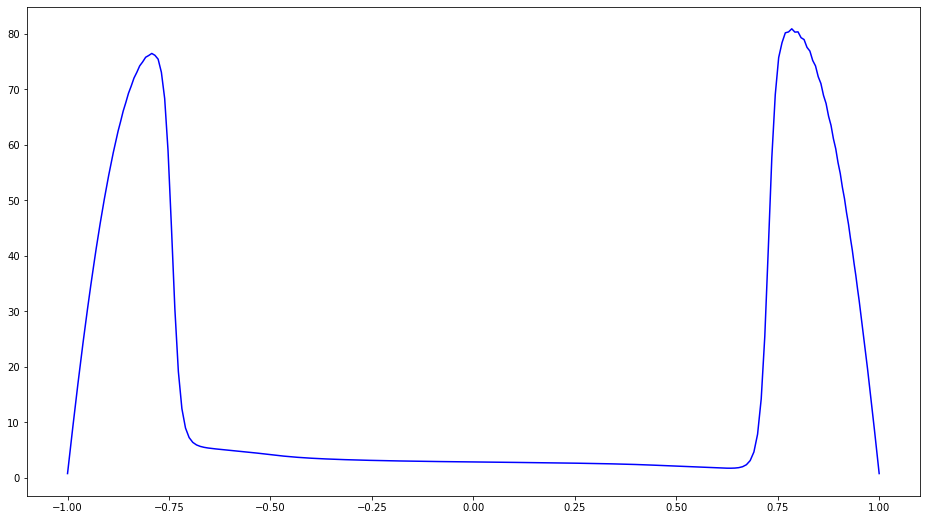

In [4]:
tds.U2 = np.load('newton_psaap_Np250.npy')

ne = tds.U2[0:tds.Np]
ni = tds.U2[tds.Np:2*tds.Np]
nT = tds.U2[2*tds.Np:]
Te = nT/ne

plt.figure(figsize=(16,9))
plt.plot(tds.xp, Te, 'b-')
plt.show()